# ConvNeXt Tiny Unfreeze Comparison (30 / 60 / 90)

This notebook keeps the dataset, preprocessing, augmentation, and optimizer setup fixed, and compares three stage-2 unfreezing depths: 30, 60, and 90 layers.

In [2]:
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow import keras

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("TF version:", tf.__version__)
print("GPU:", gpus)


TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def count_files_by_class(root_dir):
    counts = {}
    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        counts[class_name] = sum(
            1
            for file_name in os.listdir(class_dir)
            if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
        )
    return counts

def summarize_labels(ds, class_names):
    counts = Counter()
    for _, labels in ds:
        labels = labels.numpy().astype("int32").reshape(-1)
        counts.update(labels.tolist())
    return {class_names[idx]: counts.get(idx, 0) for idx in range(len(class_names))}

def collect_predictions(ds, model):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pb = model.predict(xb, verbose=0).reshape(-1)
        y_true.append(yb.numpy().reshape(-1))
        y_prob.append(pb)
    return np.concatenate(y_true).astype("int32"), np.concatenate(y_prob)


In [4]:
data_dir = "/mnt/e/DDSM/ROI"
assert os.path.exists(data_dir), f"Dataset path not found: {data_dir}"
print("Using data_dir:", data_dir)
print("Raw file counts by class:", count_files_by_class(data_dir))

img_size = (224, 224)
batch_size = 16
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Positive class for AUC/ROC: {class_names[1]}")

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
val_batches = max(1, temp_card // 2)
test_batches = temp_card - val_batches
if test_batches == 0:
    raise ValueError("Test split is empty. Reduce batch_size or use more data.")

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_ds_prep = prepare(train_ds, shuffle=True)
val_ds_prep = prepare(val_ds)
test_ds_prep = prepare(test_ds)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())
print("Train label counts:", summarize_labels(train_ds, class_names))
print("Validation label counts:", summarize_labels(val_ds, class_names))
print("Test label counts:", summarize_labels(test_ds, class_names))


Using data_dir: /mnt/e/DDSM/ROI
Raw file counts by class: {'ROI_Benign': 1402, 'ROI_Cancer': 1428}
Found 2830 files belonging to 2 classes.
Using 2264 files for training.


I0000 00:00:1773191384.987576    8971 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2830 files belonging to 2 classes.
Using 566 files for validation.
Classes: ['ROI_Benign', 'ROI_Cancer']
Positive class for AUC/ROC: ROI_Cancer
Train batches: 142
Validation batches: 18
Test batches: 18


2026-03-11 09:10:22.548538: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train label counts: {'ROI_Benign': 1123, 'ROI_Cancer': 1141}


2026-03-11 09:10:27.355192: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Validation label counts: {'ROI_Benign': 146, 'ROI_Cancer': 142}
Test label counts: {'ROI_Benign': 143, 'ROI_Cancer': 135}


In [5]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(0.20),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.20),
], name="data_augmentation")

def build_convnext_model():
    backbone = keras.applications.ConvNeXtTiny(
        include_top=False,
        include_preprocessing=False,
        weights="imagenet",
        input_shape=img_size + (3,),
        pooling="avg",
        name="convnext_tiny",
    )
    preprocessing = keras.Sequential(
        [keras.layers.Rescaling(1.0 / 255)],
        name="preprocessing",
    )
    inputs = keras.Input(shape=img_size + (3,))
    x = preprocessing(inputs)
    x = data_augmentation(x)
    x = backbone(x, training=False)
    x = keras.layers.Dense(256, activation="gelu")(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid", dtype="float32", name="cancer_prob")(x)
    model = keras.Model(inputs, outputs)
    return model

model = build_convnext_model()
model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 768)            │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cancer_prob (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,017,249 (106.88 MB)

 Trainable params: 28,017,249 (106.88 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
backbone = model.get_layer("convnext_tiny")
backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

stage1_trainable_weights = len(model.trainable_weights)
print("Stage 1 trainable weights:", stage1_trainable_weights)

stage1_ckpt = "/mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1_comparison.keras"
cb1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_ckpt,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=10,
    callbacks=cb1,
    verbose=1,
)


Stage 1 trainable weights: 4
Epoch 1/10


2026-03-11 09:10:59.905134: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 55 of 1000
2026-03-11 09:11:19.647982: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-03-11 09:11:22.653059: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
2026-03-11 09:11:29.657339: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ca703932cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-11 09:11:29.657390: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
I0000 00:00:1773191493.849849   11121 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - acc: 0.5085 - auc: 0.5197 - loss: 0.7875 - precision: 0.5122 - recall: 0.5218
Epoch 1: val_auc improved from None to 0.65380, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1_comparison.keras

Epoch 1: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1_comparison.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 86s 215ms/step - acc: 0.5314 - auc: 0.5451 - loss: 0.7714 - precision: 0.5348 - recall: 0.5390 - val_acc: 0.6042 - val_auc: 0.6538 - val_loss: 0.6673 - val_precision: 0.6000 - val_recall: 0.8077
Epoch 2/10


2026-03-11 09:12:19.600761: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 48 of 1000
2026-03-11 09:12:39.197845: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - acc: 0.5724 - auc: 0.6114 - loss: 0.7013 - precision: 0.5756 - recall: 0.5897
Epoch 2: val_auc improved from 0.65380 to 0.71946, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1_comparison.keras

Epoch 2: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1_comparison.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 54s 171ms/step - acc: 0.5822 - auc: 0.6179 - loss: 0.6978 - precision: 0.5868 - recall: 0.5776 - val_acc: 0.6181 - val_auc: 0.7195 - val_loss: 0.6443 - val_precision: 0.5845 - val_recall: 0.8345
Epoch 3/10


2026-03-11 09:13:13.741903: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 49 of 1000
2026-03-11 09:13:23.918686: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 96 of 1000
2026-03-11 09:13:32.881287: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - acc: 0.5632 - auc: 0.6024 - loss: 0.6990 - precision: 0.5577 - recall: 0.5578
Epoch 3: val_auc did not improve from 0.71946
142/142 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - acc: 0.5870 - auc: 0.6329 - loss: 0.6795 - precision: 0.5904 - recall: 0.5898 - val_acc: 0.6076 - val_auc: 0.6838 - val_loss: 0.6568 - val_precision: 0.5891 - val_recall: 0.7987
Epoch 4/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - acc: 0.6288 - auc: 0.6738 - loss: 0.6517 - precision: 0.6388 - recall: 0.6395
Epoch 4: val_auc did not improve from 0.71946
142/142 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - acc: 0.6228 - auc: 0.6672 - loss: 0.6570 - precision: 0.6289 - recall: 0.6135 - val_acc: 0.6389 - val_auc: 0.6916 - val_loss: 0.6324 - val_precision: 0.6767 - val_recall: 0.5960
Epoch 5/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - acc: 0.6178 - auc: 0.6680 - loss: 0.6488 - precision: 0.6269 - recall: 0.5983
Epoch 5: val_auc improved from 0.71946 to 0.75312, saving model to /m

In [7]:
unfreeze_candidates = [30, 60, 90, 120, 150]
comparison_results = []
comparison_histories = {}

for num_layers_to_unfreeze in unfreeze_candidates:
    print(f"\n===== Stage 2 experiment: unfreeze last {num_layers_to_unfreeze} layers =====")
    stage2_model = keras.models.load_model(stage1_ckpt, compile=False)
    stage2_backbone = stage2_model.get_layer("convnext_tiny")

    stage2_backbone.trainable = True
    for layer in stage2_backbone.layers:
        layer.trainable = False
    fine_tune_layers = stage2_backbone.layers[-num_layers_to_unfreeze:]
    for layer in fine_tune_layers:
        layer.trainable = True

    print("ConvNeXt backbone layers:", len(stage2_backbone.layers))
    print("Unfrozen last layers:", num_layers_to_unfreeze)
    print("Stage 2 trainable weights:", len(stage2_model.trainable_weights))

    stage2_model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(name="auc"),
            keras.metrics.BinaryAccuracy(name="acc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )

    ckpt_path = f"/mnt/e/SW_training_outputs/checkpoints/best_convnext_unfreeze_{num_layers_to_unfreeze}.keras"
    cb2 = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    history2 = stage2_model.fit(
        train_ds_prep,
        validation_data=val_ds_prep,
        epochs=25,
        callbacks=cb2,
        verbose=1,
    )
    comparison_histories[num_layers_to_unfreeze] = history2

    best_model = keras.models.load_model(ckpt_path)
    best_model.compile(
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(name="auc"),
            keras.metrics.BinaryAccuracy(name="acc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    test_metrics = best_model.evaluate(test_ds_prep, return_dict=True, verbose=1)
    test_true, test_prob = collect_predictions(test_ds_prep, best_model)
    test_pred = (test_prob >= 0.5).astype("int32")

    comparison_results.append({
        "unfreeze_layers": num_layers_to_unfreeze,
        "ckpt_path": ckpt_path,
        "best_val_auc": float(max(history2.history["val_auc"])),
        "test_auc": float(roc_auc_score(test_true, test_prob)),
        "test_acc": float(accuracy_score(test_true, test_pred)),
        "test_loss": float(test_metrics["loss"]),
        "test_precision": float(test_metrics["precision"]),
        "test_recall": float(test_metrics["recall"]),
    })

comparison_results = sorted(comparison_results, key=lambda item: item["test_auc"], reverse=True)
best_result = comparison_results[0]
best_unfreeze = best_result["unfreeze_layers"]
best_ckpt_path = best_result["ckpt_path"]
print("\nBest setting by test AUC:", best_result)



===== Stage 2 experiment: unfreeze last 30 layers =====
ConvNeXt backbone layers: 133
Unfrozen last layers: 30
Stage 2 trainable weights: 44
Epoch 1/25


2026-03-11 09:16:18.652024: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 40 of 1000
2026-03-11 09:16:38.487347: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 131 of 1000
2026-03-11 09:16:40.353465: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-03-11 09:16:44.896519: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng46{k2=5,k5=3,k14=4} for conv (f32[1,768,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,12288,7,7]{3,2,1,0}, f32[768,16,7,7]{3,2,1,0}), window={size=7x7 pad=3_3x3_3}, dim_labels=bf01_oi01->bf01, feature_group_count=768, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha"

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - acc: 0.6388 - auc: 0.6897 - loss: 0.6379 - precision: 0.6467 - recall: 0.6078
Epoch 1: val_auc improved from None to 0.70641, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_unfreeze_30.keras

Epoch 1: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_unfreeze_30.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 128s 512ms/step - acc: 0.6343 - auc: 0.6844 - loss: 0.6400 - precision: 0.6495 - recall: 0.5960 - val_acc: 0.6875 - val_auc: 0.7064 - val_loss: 0.6270 - val_precision: 0.7265 - val_recall: 0.5944
Epoch 2/25


2026-03-11 09:18:10.147454: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 45 of 1000
2026-03-11 09:18:29.976659: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 128 of 1000
2026-03-11 09:18:36.533721: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - acc: 0.6364 - auc: 0.6982 - loss: 0.6286 - precision: 0.6518 - recall: 0.6017
Epoch 2: val_auc improved from 0.70641 to 0.72984, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_unfreeze_30.keras

Epoch 2: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_unfreeze_30.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 109s 508ms/step - acc: 0.6422 - auc: 0.6966 - loss: 0.6313 - precision: 0.6593 - recall: 0.6004 - val_acc: 0.7014 - val_auc: 0.7298 - val_loss: 0.6064 - val_precision: 0.7090 - val_recall: 0.6690
Epoch 3/25


...


===== Stage 2 experiment: unfreeze last 90 layers =====
ConvNeXt backbone layers: 133
Unfrozen last layers: 90
Stage 2 trainable weights: 123
Epoch 1/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - acc: 0.6465 - auc: 0.6909 - loss: 0.6387 - precision: 0.6541 - recall: 0.6286
Epoch 1: val_auc improved from None to 0.72073, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_unfreeze_90.keras

Epoch 1: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_unfreeze_90.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 120s 659ms/step - acc: 0.6409 - auc: 0.6934 - loss: 0.6361 - precision: 0.6507 - recall: 0.6205 - val_acc: 0.6736 - val_auc: 0.7207 - val_loss: 0.6107 - val_precision: 0.6880 - val_recall: 0.6099
Epoch 2/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - acc: 0.6622 - auc: 0.7087 - loss: 0.6188 - precision: 0.6843 - recall: 0.6144
Epoch 2: val_auc improved from 0.72073 to 0.72154, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_unf

2026-03-11 09:51:35.985888: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-11 09:51:41.075748: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


===== Stage 2 experiment: unfreeze last 120 layers =====
ConvNeXt backbone layers: 133
Unfrozen last layers: 120
Stage 2 trainable weights: 165
Epoch 1/25


2026-03-11 09:52:09.398213: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-03-11 09:52:21.457579: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.30MiB (rounded to 2408448)requested by op StatefulPartitionedCall/functional_6_1/convnext_tiny_1/convnext_tiny_stage_3_block_1_pointwise_conv_2_1/MatMul
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-03-11 09:52:21.457678: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
2026-03-11 09:52:21.457684: I

ResourceExhaustedError: Graph execution error:

Detected at node functional_6_1/convnext_tiny_1/convnext_tiny_stage_3_block_1_pointwise_conv_2_1/MatMul defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/dell/miniconda3/envs/tf218/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/home/dell/miniconda3/envs/tf218/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File

ConvNeXt unfreeze comparison summary (sorted by test AUC):
unfreeze= 30 | val_auc=0.7298 | test_auc=0.6816 | test_acc=0.6403 | precision=0.6748 | recall=0.6194
unfreeze= 60 | val_auc=0.7588 | test_auc=0.7212 | test_acc=0.6403 | precision=0.6454 | recall=0.6454
unfreeze= 90 | val_auc=0.7788 | test_auc=0.7511 | test_acc=0.6906 | precision=0.6690 | recall=0.6643


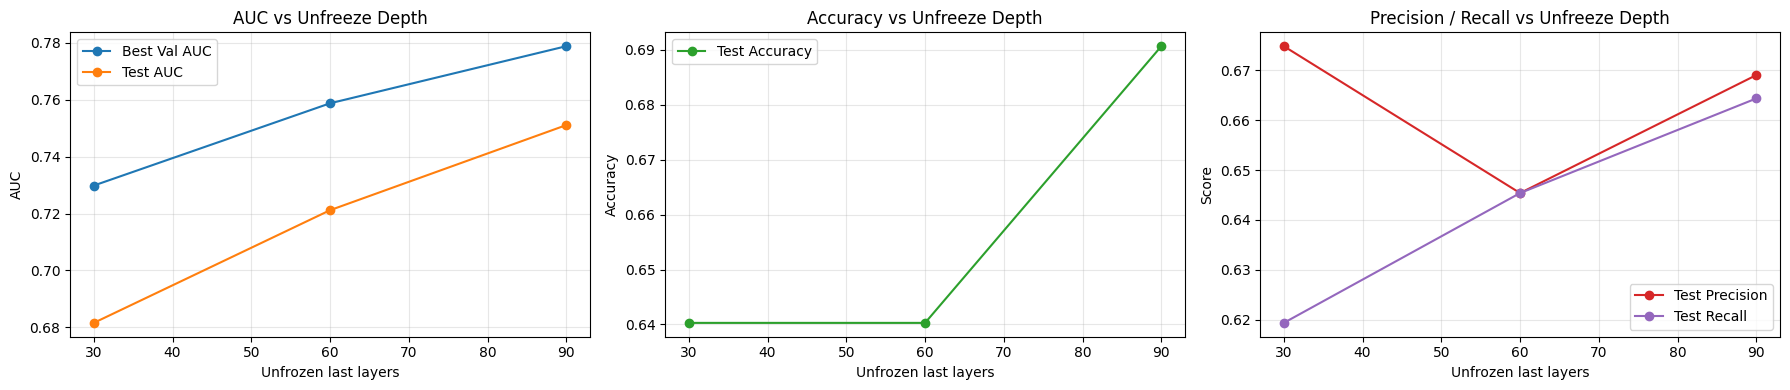

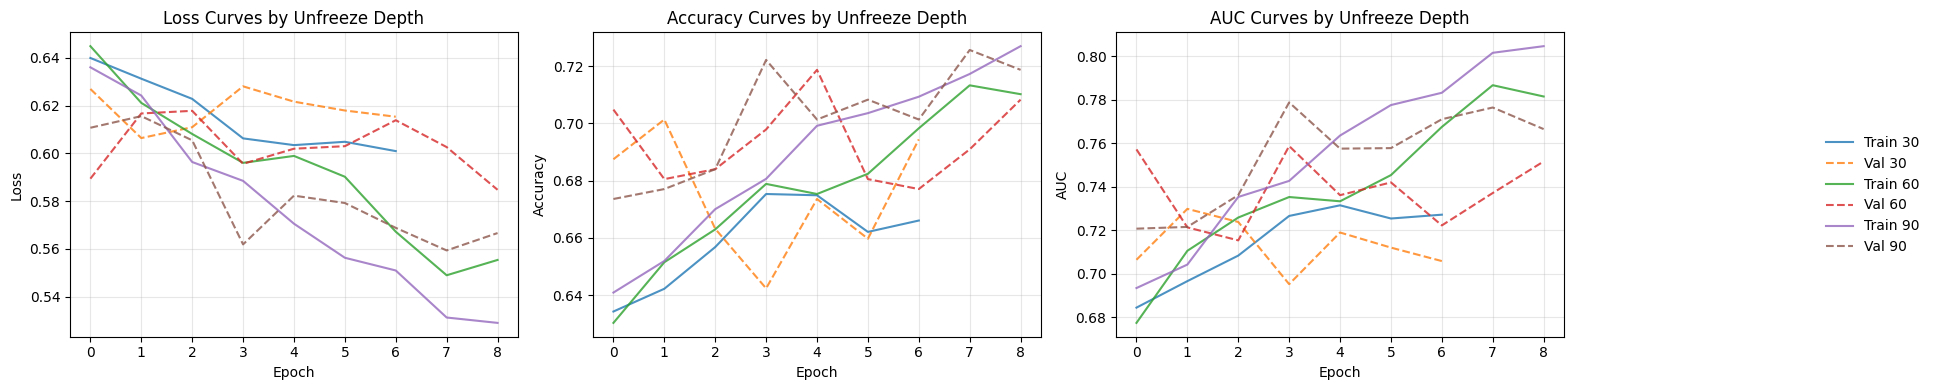

In [8]:
print("ConvNeXt unfreeze comparison summary (sorted by test AUC):")
for result in comparison_results:
    print(
        f"unfreeze={result['unfreeze_layers']:>3} | "
        f"val_auc={result['best_val_auc']:.4f} | "
        f"test_auc={result['test_auc']:.4f} | "
        f"test_acc={result['test_acc']:.4f} | "
        f"precision={result['test_precision']:.4f} | "
        f"recall={result['test_recall']:.4f}"
    )

# Plot in ascending order of unfreeze depth, even though the summary above is sorted by test AUC.
plot_results = sorted(comparison_results, key=lambda item: item["unfreeze_layers"])
unfreeze_values = [item["unfreeze_layers"] for item in plot_results]
test_auc_values = [item["test_auc"] for item in plot_results]
test_acc_values = [item["test_acc"] for item in plot_results]
val_auc_values = [item["best_val_auc"] for item in plot_results]
test_precision_values = [item["test_precision"] for item in plot_results]
test_recall_values = [item["test_recall"] for item in plot_results]

plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
plt.plot(unfreeze_values, val_auc_values, marker="o", label="Best Val AUC")
plt.plot(unfreeze_values, test_auc_values, marker="o", label="Test AUC")
plt.xlabel("Unfrozen last layers")
plt.ylabel("AUC")
plt.title("AUC vs Unfreeze Depth")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(unfreeze_values, test_acc_values, marker="o", color="tab:green", label="Test Accuracy")
plt.xlabel("Unfrozen last layers")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Unfreeze Depth")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(unfreeze_values, test_precision_values, marker="o", color="tab:red", label="Test Precision")
plt.plot(unfreeze_values, test_recall_values, marker="o", color="tab:purple", label="Test Recall")
plt.xlabel("Unfrozen last layers")
plt.ylabel("Score")
plt.title("Precision / Recall vs Unfreeze Depth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Compare training curves across all unfreeze depths.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for depth in sorted(comparison_histories):
    history = comparison_histories[depth].history
    axes[0].plot(history["loss"], label=f"Train {depth}", alpha=0.8)
    axes[0].plot(history["val_loss"], linestyle="--", label=f"Val {depth}", alpha=0.8)
    axes[1].plot(history["acc"], label=f"Train {depth}", alpha=0.8)
    axes[1].plot(history["val_acc"], linestyle="--", label=f"Val {depth}", alpha=0.8)
    axes[2].plot(history["auc"], label=f"Train {depth}", alpha=0.8)
    axes[2].plot(history["val_auc"], linestyle="--", label=f"Val {depth}", alpha=0.8)

axes[0].set_title("Loss Curves by Unfreeze Depth")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Accuracy Curves by Unfreeze Depth")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("AUC Curves by Unfreeze Depth")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].grid(True, alpha=0.3)

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


In [ ]:
best_model = keras.models.load_model(best_ckpt_path)
best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
print("Loaded best comparison model from:", best_ckpt_path)
print("Best unfreeze depth:", best_unfreeze)

test_metrics = best_model.evaluate(test_ds_prep, return_dict=True)
print("Evaluation metrics:", test_metrics)

test_true, test_prob = collect_predictions(test_ds_prep, best_model)
test_pred = (test_prob >= 0.5).astype("int32")
test_fpr, test_tpr, _ = roc_curve(test_true, test_prob)
test_auc = roc_auc_score(test_true, test_prob)
test_acc = accuracy_score(test_true, test_pred)
cm = confusion_matrix(test_true, test_pred)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(test_true, test_pred, target_names=class_names))

plt.figure(figsize=(6, 6))
plt.plot(test_fpr, test_tpr, label=f"ROC curve (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Best Depth = {best_unfreeze})")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Final test-metric comparison across all unfreeze settings.
plot_results = sorted(comparison_results, key=lambda item: item["unfreeze_layers"])
depth_labels = [str(item["unfreeze_layers"]) for item in plot_results]
metric_names = ["test_auc", "test_acc", "test_precision", "test_recall"]
metric_titles = ["Test AUC", "Test Accuracy", "Test Precision", "Test Recall"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric_name, metric_title in zip(axes, metric_names, metric_titles):
    metric_values = [item[metric_name] for item in plot_results]
    bars = ax.bar(depth_labels, metric_values, color="tab:blue", alpha=0.85)
    ax.set_title(metric_title)
    ax.set_xlabel("Unfrozen last layers")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    for bar, value in zip(bars, metric_values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Score")
plt.tight_layout()
plt.show()

best_history = comparison_histories[best_unfreeze]
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(best_history.history["loss"], label="Train Loss")
plt.plot(best_history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(best_history.history["acc"], label="Train Accuracy")
plt.plot(best_history.history["val_acc"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(best_history.history["auc"], label="Train AUC")
plt.plot(best_history.history["val_auc"], label="Val AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


NameError: name 'best_ckpt_path' is not defined

: 